<a href="https://colab.research.google.com/github/ravindyaparami/multi-agents-on-a-lie-group/blob/main/Drake/Communication%20ad%20Consensus.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np

class Controller:
    """
    Base class for all controllers.
    """

    def compute_control(self, t, self_state, neighbor_states):
        """
        Compute force and torque for one agent.

        Parameters
        ----------
        t : float
            Current simulation time.

        self_state : AgentState
            Current state of this agent.

        neighbor_states : dict
            Neighbor agent states. Empty in Milestone 3.

        Returns
        -------
        force : np.ndarray, shape (3,)
            Force expressed in world frame.

        torque : np.ndarray, shape (3,)
            Torque expressed in world frame.
        """
        raise NotImplementedError


In [ ]:
class ZeroController(Controller):
    """
    Controller that applies no force and no torque.
    Useful as a default controller.
    """

    def compute_control(self, t, self_state, neighbor_states):
        force = np.zeros(3)
        torque = np.zeros(3)
        return force, torque

In [ ]:
class Agent:
    def __init__(self, agent_id, config, controller=None):
        self.id = agent_id
        self.config = config
        self.controller = (
            controller
            if controller is not None
            else ZeroController()
        )

        self.body = None

In [ ]:
class AgentState:
    """
    Clean simulator-level state of one rigid-body agent.

    This class hides Drake-specific pose and velocity objects.
    Controllers and loggers should use this class instead of directly
    using Drake's q, v, RigidTransform, or SpatialVelocity objects.
    """

    def __init__(self,
                 position,
                 orientation,
                 linear_velocity,
                 angular_velocity):

        self.position = np.array(position, dtype=float)
        self.orientation = np.array(orientation, dtype=float)
        self.linear_velocity = np.array(linear_velocity, dtype=float)
        self.angular_velocity = np.array(angular_velocity, dtype=float)

        self._validate()

    def _validate(self):
        if self.position.shape != (3,):
            raise ValueError("Position must be a 3D vector.")

        if self.orientation.shape != (3, 3):
            raise ValueError("Orientation must be a 3x3 rotation matrix.")

        if not np.allclose(self.orientation.T @ self.orientation, np.eye(3), atol=1e-6):
            raise ValueError("Orientation must satisfy R^T R = I.")

        if not np.isclose(np.linalg.det(self.orientation), 1.0, atol=1e-6):
            raise ValueError("Orientation matrix must have determinant +1.")

        if self.linear_velocity.shape != (3,):
            raise ValueError("Linear velocity must be a 3D vector.")

        if self.angular_velocity.shape != (3,):
            raise ValueError("Angular velocity must be a 3D vector.")

    def as_dict(self):
        return {
            "position": self.position,
            "orientation": self.orientation,
            "linear_velocity": self.linear_velocity,
            "angular_velocity": self.angular_velocity
        }

In [ ]:
class SimulationLogger:
    """
    Logs agent states and computes consensus error during simulation.

    This logger is intentionally simulator-level, not Drake-specific.
    It records clean AgentState objects returned by get_all_agent_states().
    """

    def __init__(self, agent_ids):
        self.agent_ids = list(agent_ids)

        self.times = []

        self.positions = {
            agent_id: []
            for agent_id in self.agent_ids
        }

        self.linear_velocities = {
            agent_id: []
            for agent_id in self.agent_ids
        }

        self.consensus_errors = []

    def record(self, t, states):
        """
        Record one simulation sample.

        Parameters
        ----------
        t : float
            Current simulation time.

        states : dict
            Dictionary of agent_id -> AgentState.
        """

        self.times.append(float(t))

        for agent_id in self.agent_ids:
            state = states[agent_id]

            self.positions[agent_id].append(
                np.array(state.position, dtype=float)
            )

            self.linear_velocities[agent_id].append(
                np.array(state.linear_velocity, dtype=float)
            )

        error = self.compute_position_consensus_error(states)
        self.consensus_errors.append(error)

    def compute_position_consensus_error(self, states):
        """
        Compute RMS position disagreement.

        If all agents have the same position, this value becomes zero.
        """

        positions = np.array([
            states[agent_id].position
            for agent_id in self.agent_ids
        ])

        mean_position = np.mean(positions, axis=0)

        differences = positions - mean_position

        squared_distances = np.sum(differences ** 2, axis=1)

        rms_error = np.sqrt(np.mean(squared_distances))

        return float(rms_error)

    def as_arrays(self):
        """
        Convert logged lists into NumPy arrays.
        Useful before plotting.
        """

        data = {
            "time": np.array(self.times),
            "consensus_error": np.array(self.consensus_errors),
            "positions": {},
            "linear_velocities": {}
        }

        for agent_id in self.agent_ids:
            data["positions"][agent_id] = np.array(
                self.positions[agent_id]
            )

            data["linear_velocities"][agent_id] = np.array(
                self.linear_velocities[agent_id]
            )

        return data

In [ ]:
import matplotlib.pyplot as plt

def plot_consensus_error(logger):
    """
    Plot position consensus error versus time.
    """

    data = logger.as_arrays()

    time = data["time"]
    error = data["consensus_error"]

    plt.figure()
    plt.plot(time, error)
    plt.xlabel("Time (s)")
    plt.ylabel("Position consensus error (m)")
    plt.title("Position Consensus Error")
    plt.grid(True)
    plt.show()

def plot_agent_x_positions(logger):
    """
    Plot x-position of each agent versus time.
    """

    data = logger.as_arrays()

    time = data["time"]

    plt.figure()

    for agent_id, positions in data["positions"].items():
        x_positions = positions[:, 0]
        plt.plot(time, x_positions, label=f"Agent {agent_id}")

    plt.xlabel("Time (s)")
    plt.ylabel("x position (m)")
    plt.title("Agent x Positions")
    plt.legend()
    plt.grid(True)
    plt.show()

def plot_3d_trajectories(logger):
    """
    Plot 3D trajectories of all agents.
    """

    data = logger.as_arrays()

    fig = plt.figure()
    ax = fig.add_subplot(111, projection="3d")

    for agent_id, positions in data["positions"].items():
        ax.plot(
            positions[:, 0],
            positions[:, 1],
            positions[:, 2],
            label=f"Agent {agent_id}"
        )

        # Mark starting point
        ax.scatter(
            positions[0, 0],
            positions[0, 1],
            positions[0, 2],
            marker="o"
        )

        # Mark ending point
        ax.scatter(
            positions[-1, 0],
            positions[-1, 1],
            positions[-1, 2],
            marker="x"
        )

    ax.set_xlabel("x (m)")
    ax.set_ylabel("y (m)")
    ax.set_zlabel("z (m)")
    ax.set_title("Agent Trajectories")
    ax.legend()
    plt.show()

In [ ]:
import numpy as np
class EnvironmentConfig:
    def __init__(self, gravity=None):
        self.gravity = (
            np.array(gravity, dtype=float)
            if gravity is not None
            else np.array([0.0, 0.0, -9.81])
        )

        self._validate()

    def _validate(self):
        if self.gravity.shape != (3,):
            raise ValueError("Gravity must be a 3D vector.")

In [ ]:
import networkx as nx
import itertools

class CommunicationGraph:
    """
    Communication topology between agents.

    Each node is an agent ID.
    Each edge represents communication between agents.

    For now, we use an undirected graph:
        edge (i, j) means agent i can receive from j
        and agent j can receive from i.

    Later, this can be extended to directed graphs, delays,
    packet loss, and time-varying communication.
    """

    def __init__(self, agent_ids, edges=None, directed=False):
        self.agent_ids = list(agent_ids)
        self.directed = directed

        if directed:
            self.graph = nx.DiGraph()
        else:
            self.graph = nx.Graph()

        self.graph.add_nodes_from(self.agent_ids)

        if edges is not None:
            self.graph.add_edges_from(edges)

        self._validate()

    def _validate(self):
        # Check all graph nodes are valid agent IDs
        for node in self.graph.nodes:
            if node not in self.agent_ids:
                raise ValueError(f"Unknown agent ID in graph: {node}")

        # Avoid self-communication for now
        for u, v in self.graph.edges:
            if u == v:
                raise ValueError("Self-edges are not allowed in the communication graph.")

    def neighbors(self, agent_id):
        """
        Return the IDs of agents whose states are available to this agent.

        For undirected graphs:
            returns adjacent nodes.

        For directed graphs:
            returns predecessors, meaning agents that send information
            to this agent.
        """

        if agent_id not in self.graph.nodes:
            raise ValueError(f"Agent ID {agent_id} is not in the communication graph.")

        if self.directed:
            return list(self.graph.predecessors(agent_id))

        return list(self.graph.neighbors(agent_id))

    def add_edge(self, agent_i, agent_j):
        self.graph.add_edge(agent_i, agent_j)
        self._validate()

    def remove_edge(self, agent_i, agent_j):
        self.graph.remove_edge(agent_i, agent_j)

    def edges(self):
        return list(self.graph.edges())

    def nodes(self):
        return list(self.graph.nodes())

    def number_of_edges(self):
        return self.graph.number_of_edges()

    def number_of_nodes(self):
        return self.graph.number_of_nodes()

    @classmethod
    def empty(cls, agent_ids):
        """
        No communication between agents.
        """
        return cls(agent_ids=agent_ids, edges=[])

    @classmethod
    def complete(cls, agent_ids):
        """
        Every agent communicates with every other agent.
        """
        edges = list(itertools.combinations(agent_ids, 2))
        return cls(agent_ids=agent_ids, edges=edges)

    @classmethod
    def chain(cls, agent_ids):
        """
        Chain topology:
            0 -- 1 -- 2 -- 3
        """
        agent_ids = list(agent_ids)
        edges = []

        for i in range(len(agent_ids) - 1):
            edges.append((agent_ids[i], agent_ids[i + 1]))

        return cls(agent_ids=agent_ids, edges=edges)

    @classmethod
    def ring(cls, agent_ids):
        """
        Ring topology:
            0 -- 1 -- 2 -- 3 -- 0
        """
        agent_ids = list(agent_ids)
        edges = []

        for i in range(len(agent_ids)):
            edges.append((agent_ids[i], agent_ids[(i + 1) % len(agent_ids)]))

        return cls(agent_ids=agent_ids, edges=edges)

In [ ]:
import numpy as np

class BodyConfig:
    """
    Configuration for a general rigid body.
    Defined purely by mass and inertia tensor.
    """

    def __init__(self,
                 mass: float,
                 inertia_matrix: np.ndarray,
                 initial_position=None,
                 initial_orientation=None,
                 initial_angular_velocity=None,
                 initial_linear_velocity=None,
                 #gravity=None,
                 friction=(0.9, 0.8),
                 size=(0.2, 0.2, 0.2),
                 color=(0.2, 0.6, 1.0, 1.0)
                 ):

        # ---- Fundamental physical properties ----
        self.mass = float(mass)
        self.inertia_matrix = np.array(inertia_matrix, dtype=float)

        # ---- Initial position ----
        self.initial_position = (
            np.array(initial_position, dtype=float)
            if initial_position is not None
            else np.array([0.0, 0.0, 1.0])
        )

        # Orientation stored as rotation matrix (3x3)
        self.initial_orientation = (
            np.array(initial_orientation, dtype=float)
            if initial_orientation is not None
            else np.eye(3)
        )

        # ---- Initial Angular velocity ----
        self.initial_angular_velocity = (
            np.array(initial_angular_velocity, dtype=float)
            if initial_angular_velocity is not None
            else np.zeros(3)
        )

        # ---- Initial Linear velocity ----
        self.initial_linear_velocity = (
            np.array(initial_linear_velocity, dtype=float)
            if initial_linear_velocity is not None
            else np.zeros(3)
        )

        #---- Optional simulation properties ----
        '''
        self.gravity = (
            np.array(gravity, dtype=float)
            if gravity is not None
            else np.array([0.0, 0.0, -9.81])
        )
        '''

        self.friction = friction
        self.size = np.array(size, dtype=float)
        self.color = np.array(color, dtype=float)

        # ---- Validate physical correctness ----
        self._validate()

    def _validate(self):
        if self.mass <= 0:
            raise ValueError("Mass must be positive.")

        if self.inertia_matrix.shape != (3, 3):
            raise ValueError("Inertia matrix must be 3x3.")

        # Must be symmetric
        if not np.allclose(self.inertia_matrix,
                           self.inertia_matrix.T):
            raise ValueError("Inertia matrix must be symmetric.")

        # Must be positive definite
        eigenvalues = np.linalg.eigvalsh(self.inertia_matrix)
        if not np.all(eigenvalues > 0):
            raise ValueError(
                "Inertia matrix must be positive definite."
            )

        # ---- Rotation matrix validity ----
        R = self.initial_orientation

        if R.shape != (3, 3):
            raise ValueError("Initial orientation must be 3x3.")

        # Check orthogonality: R^T R ≈ I
        if not np.allclose(R.T @ R, np.eye(3), atol=1e-6):
            raise ValueError("Orientation matrix must be orthogonal (R^T R = I).")

        # Check determinant: det(R) ≈ 1
        det_R = np.linalg.det(R)
        if not np.isclose(det_R, 1.0, atol=1e-6):
            raise ValueError("Orientation matrix must have determinant +1.")

        # ---- Initial Angular and Linear Velocities validity ----
        if self.initial_linear_velocity.shape != (3,):
            raise ValueError("Initial linear velocity must be a 3D vector.")

        if self.initial_angular_velocity.shape != (3,):
            raise ValueError("Initial angular velocity must be a 3D vector.")

        if self.size.shape != (3,):
            raise ValueError("Body size must be a 3D vector.")

        if np.any(self.size <= 0):
            raise ValueError("Body size values must be positive.")

        if self.color.shape != (4,):
            raise ValueError("Color must be RGBA with 4 values.")



In [ ]:
from pydrake.all import LeafSystem, Value, ExternallyAppliedSpatialForce, SpatialForce
import numpy as np


class ExternalForceSystem(LeafSystem):
    """
    Applies each agent's controller-generated force and torque to Drake.
    Neighbor states are selected using the communication graph.
    """

    def __init__(self, plant, agents, communication_graph=None):
        super().__init__()

        self.plant = plant
        self.agents = agents

        agent_ids = [agent.id for agent in agents]

        self.communication_graph = (
            communication_graph
            if communication_graph is not None
            else CommunicationGraph.empty(agent_ids)
        )

        self.DeclareVectorInputPort(
            "plant_state",
            plant.num_positions() + plant.num_velocities()
        )

        self.DeclareAbstractOutputPort(
            "spatial_forces",
            lambda: Value([ExternallyAppliedSpatialForce()]),
            self.CalcOutput
        )

    def CalcOutput(self, context, output):
        forces = []

        # Current simulation time
        t = context.get_time()

        # Read full Drake plant state
        state = self.EvalVectorInput(context, 0).value()

        # Create a temporary plant context for state extraction
        plant_context = self.plant.CreateDefaultContext()
        self.plant.SetPositionsAndVelocities(
            plant_context,
            state
        )

        # Convert Drake state to AgentState objects
        all_states = {}

        for agent in self.agents:
            pose = self.plant.GetFreeBodyPose(
                plant_context,
                agent.body
            )

            velocity = self.plant.EvalBodySpatialVelocityInWorld(
                plant_context,
                agent.body
            )

            all_states[agent.id] = AgentState(
                position=pose.translation(),
                orientation=pose.rotation().matrix(),
                linear_velocity=velocity.translational(),
                angular_velocity=velocity.rotational()
            )

        # Ask each agent controller for force and torque
        for agent in self.agents:
            self_state = all_states[agent.id]

            # No neighbor communication yet in Milestone 4
            neighbor_ids = self.communication_graph.neighbors(agent.id)

            neighbor_states = {
                neighbor_id: all_states[neighbor_id]
                for neighbor_id in neighbor_ids
            }

            force_vec, torque_vec = agent.controller.compute_control(
                t=t,
                self_state=self_state,
                neighbor_states=neighbor_states
            )

            force_vec = np.array(force_vec, dtype=float)
            torque_vec = np.array(torque_vec, dtype=float)

            if force_vec.shape != (3,):
                raise ValueError(
                    f"Controller force for Agent {agent.id} must be a 3D vector."
                )

            if torque_vec.shape != (3,):
                raise ValueError(
                    f"Controller torque for Agent {agent.id} must be a 3D vector."
                )

            spatial_force = ExternallyAppliedSpatialForce()
            spatial_force.body_index = agent.body.index()

            # Apply force at body origin/COM
            spatial_force.p_BoBq_B = np.zeros(3)

            spatial_force.F_Bq_W = SpatialForce(
                tau=torque_vec,
                f=force_vec
            )

            forces.append(spatial_force)

        output.set_value(forces)

In [ ]:
from pydrake.all import *
import numpy as np
from pydrake.all import SpatialVelocity

class MultiAgentSimulator:
    """
    Drake-based simulator for multiple free rigid-body agents
    with configurable environment and external spatial forces.
    """
    def __init__(self, agents, time_step: float = 0.001, environment=None, communication_graph=None):
        self.agents = agents
        self.agent_map = {agent.id: agent for agent in agents}
        self.time_step = time_step
        self.environment = environment or EnvironmentConfig()

        agent_ids = [agent.id for agent in agents]

        self.communication_graph = (
            communication_graph
            if communication_graph is not None
            else CommunicationGraph.empty(agent_ids)
        )

        self._validate_communication_graph()

        self._build_system()

    def _validate_communication_graph(self):
        """
        Check that the communication graph uses only valid agent IDs.
        """

        valid_ids = set(self.agent_map.keys())
        graph_ids = set(self.communication_graph.nodes())

        if graph_ids != valid_ids:
            raise ValueError(
                f"Communication graph nodes {graph_ids} do not match agent IDs {valid_ids}."
            )

    def _build_system(self):
        # 1. Diagram & plant
        self.builder = DiagramBuilder()
        self.plant, self.scene_graph = AddMultibodyPlantSceneGraph(
            self.builder,
            MultibodyPlant(time_step=self.time_step)
        )

        # 2. Add agents
        for agent in self.agents:
            self._add_agent_body(agent)

        # 3. Add ground
        #self._add_ground()

        # Gravity
        self.plant.mutable_gravity_field().set_gravity_vector(self.environment.gravity)

        # 4. Finalize plant
        self.plant.Finalize()

        # 4.1 Add external force system if provided
        # 4.1 Add controller-based external force system
        self.force_system = ExternalForceSystem(
            self.plant,
            self.agents,
            communication_graph=self.communication_graph
        )

        self.builder.AddSystem(self.force_system)

        self.builder.Connect(
            self.plant.get_state_output_port(),
            self.force_system.get_input_port(0)
        )

        self.builder.Connect(
            self.force_system.get_output_port(),
            self.plant.get_applied_spatial_force_input_port()
        )


        # 5. Meshcat visualizer (optional, for debugging)
        self.meshcat = StartMeshcat()
        MeshcatVisualizer.AddToBuilder(
            self.builder,
            self.scene_graph,
            self.meshcat
        )

        # 6. Build diagram
        self.diagram = self.builder.Build()
        self.simulator = Simulator(self.diagram)

        # ---- SET INITIAL VELOCITIES ----
        context = self.simulator.get_mutable_context()
        plant_context = self.plant.GetMyContextFromRoot(context)

        for agent in self.agents:

            cfg = agent.config

            V_WB = SpatialVelocity(
                w=cfg.initial_angular_velocity,
                v=cfg.initial_linear_velocity
            )

            self.plant.SetFreeBodySpatialVelocity(
                agent.body,
                V_WB,
                plant_context
            )

    def _add_agent_body(self, agent):
        cfg = agent.config

        # Convert inertia matrix to UnitInertia
        I = cfg.inertia_matrix
        m = cfg.mass

        unit_inertia = UnitInertia(
            Ixx=I[0, 0]/m,
            Iyy=I[1, 1]/m,
            Izz=I[2, 2]/m,
            Ixy=I[0, 1]/m,
            Ixz=I[0, 2]/m,
            Iyz=I[1, 2]/m
        )

        spatial_inertia = SpatialInertia(
            mass=cfg.mass,
            p_PScm_E=np.zeros(3),
            G_SP_E=unit_inertia
        )

        body = self.plant.AddRigidBody(
            f"body_{agent.id}",
            spatial_inertia
        )
        agent.body = body

        # Set initial pose
        X_WB = RigidTransform(
            RotationMatrix(cfg.initial_orientation),
            cfg.initial_position
        )

        self.plant.SetDefaultFloatingBaseBodyPose(
            agent.body,
            X_WB
        )

        # Minimal placeholder collision geometry
        box_size = cfg.size
        collision_shape = Box(box_size[0], box_size[1], box_size[2])
        self.plant.RegisterCollisionGeometry(
            agent.body,
            RigidTransform(),
            collision_shape,
            "body_collision",
            CoulombFriction(*cfg.friction)
        )

        # Minimal visual geometry (for Meshcat visualization)
        visual_shape = Box(box_size[0], box_size[1], box_size[2])
        self.plant.RegisterVisualGeometry(
            agent.body,
            RigidTransform(),
            visual_shape,
            "body_visual",
            cfg.color  # RGBA color
        )

    def get_agent_state(self, agent, plant_context=None):
        """
        Extract the current physical state of one agent from Drake
        and convert it into an AgentState object.
        """

        if plant_context is None:
            context = self.simulator.get_context()
            plant_context = self.plant.GetMyContextFromRoot(context)

        pose = self.plant.GetFreeBodyPose(
            plant_context,
            agent.body
        )

        velocity = self.plant.EvalBodySpatialVelocityInWorld(
            plant_context,
            agent.body
        )

        return AgentState(
            position=pose.translation(),
            orientation=pose.rotation().matrix(),
            linear_velocity=velocity.translational(),
            angular_velocity=velocity.rotational()
        )

    def _add_ground(self):
        ground_shape = HalfSpace()
        X_WG = RigidTransform(RollPitchYaw(np.pi, 0, 0), [0, 0, 0])

        self.plant.RegisterCollisionGeometry(
            self.plant.world_body(),
            X_WG,
            ground_shape,
            "ground_collision",
            CoulombFriction(0.9, 0.8)
        )

        self.plant.RegisterVisualGeometry(
            self.plant.world_body(),
            X_WG,
            ground_shape,
            "ground_visual",
            [0.5, 0.5, 0.5, 1.0]
        )

    def simulate(self, duration: float = 5.0, realtime_rate: float = 1.0):
        self.simulator.set_target_realtime_rate(realtime_rate)
        self.simulator.Initialize()
        self.simulator.AdvanceTo(duration)

    def simulate_with_logging(self,
                          duration: float = 5.0,
                          realtime_rate: float = 1.0,
                          log_dt: float = 0.02):
        """
        Run the simulation while logging agent states.

        Parameters
        ----------
        duration : float
            Final simulation time.

        realtime_rate : float
            Drake target realtime rate.

        log_dt : float
            Time interval between logged samples.

        Returns
        -------
        logger : SimulationLogger
            Logger containing positions, velocities, and consensus error.
        """

        if log_dt <= 0:
            raise ValueError("log_dt must be positive.")

        self.simulator.set_target_realtime_rate(realtime_rate)
        self.simulator.Initialize()

        agent_ids = [agent.id for agent in self.agents]
        logger = SimulationLogger(agent_ids)

        # Record initial state at t = 0
        states = self.get_all_agent_states()
        logger.record(0.0, states)

        t = 0.0

        while t < duration:
            t_next = min(t + log_dt, duration)

            self.simulator.AdvanceTo(t_next)

            states = self.get_all_agent_states()
            logger.record(t_next, states)

            t = t_next

        return logger

    def get_web_url(self) -> str:
        return self.meshcat.web_url()

    def get_all_agent_states(self):
        """
        Return all agent states as AgentState objects.

        This version is intended for controllers, loggers, and metrics.
        """

        context = self.simulator.get_context()
        plant_context = self.plant.GetMyContextFromRoot(context)

        states = {}

        for agent in self.agents:
            states[agent.id] = self.get_agent_state(agent, plant_context)

        return states

In [ ]:
class NeighborDiagnosticController(Controller):
    """
    Controller used only for testing communication graph connections.

    It applies zero force and zero torque, but records which neighbors
    were visible during the simulation.
    """

    def __init__(self):
        self.last_neighbor_ids = []
        self.last_neighbor_count = 0

    def compute_control(self, t, self_state, neighbor_states):
        self.last_neighbor_ids = list(neighbor_states.keys())
        self.last_neighbor_count = len(neighbor_states)

        return np.zeros(3), np.zeros(3)

In [ ]:
class PositionConsensusController(Controller):
    """
    Distributed position consensus controller.

    Each agent moves toward the average behavior of its graph neighbors.

    The controller uses only:
        - self_state
        - neighbor_states

    It does not use global information about all agents.

    Force is expressed in the world frame.
    Torque is zero.
    """

    def __init__(self,
                 kp=1.0,
                 kd=2.0,
                 mass=None,
                 gravity=None,
                 force_limit=None,
                 normalize_by_degree=True):

        self.kp = float(kp)
        self.kd = float(kd)

        self.mass = (
            float(mass)
            if mass is not None
            else None
        )

        self.gravity = (
            np.array(gravity, dtype=float)
            if gravity is not None
            else None
        )

        self.force_limit = (
            float(force_limit)
            if force_limit is not None
            else None
        )

        self.normalize_by_degree = bool(normalize_by_degree)

        self._validate()

    def _validate(self):
        if self.kp < 0:
            raise ValueError("kp must be non-negative.")

        if self.kd < 0:
            raise ValueError("kd must be non-negative.")

        if self.mass is not None and self.mass <= 0:
            raise ValueError("Mass must be positive.")

        if self.gravity is not None and self.gravity.shape != (3,):
            raise ValueError("Gravity must be a 3D vector.")

        if self.gravity is not None and self.mass is None:
            raise ValueError("Mass must be provided when gravity compensation is used.")

        if self.force_limit is not None and self.force_limit <= 0:
            raise ValueError("force_limit must be positive.")

    def compute_control(self, t, self_state, neighbor_states):
        # If the agent has no neighbors, there is no consensus force.
        if len(neighbor_states) == 0:
            force = np.zeros(3)

            if self.gravity is not None:
                force = force - self.mass * self.gravity

            return force, np.zeros(3)

        position_sum = np.zeros(3)
        velocity_sum = np.zeros(3)

        for neighbor_id, neighbor_state in neighbor_states.items():
            position_sum += neighbor_state.position - self_state.position
            velocity_sum += neighbor_state.linear_velocity - self_state.linear_velocity

        # Optional normalization prevents agents with many neighbors
        # from receiving much larger force than agents with few neighbors.
        if self.normalize_by_degree:
            degree = len(neighbor_states)
            position_sum = position_sum / degree
            velocity_sum = velocity_sum / degree

        force = self.kp * position_sum + self.kd * velocity_sum

        # Gravity compensation
        if self.gravity is not None:
            force = force - self.mass * self.gravity

        # Optional force saturation
        if self.force_limit is not None:
            norm_force = np.linalg.norm(force)

            if norm_force > self.force_limit:
                force = force / norm_force * self.force_limit

        torque = np.zeros(3)

        return force, torque

In [ ]:
import numpy as np

# -----------------------------
# Environment
# -----------------------------

env = EnvironmentConfig(
    gravity=np.array([0.0, 0.0, 0.0])
)

# -----------------------------
# Body configurations
# -----------------------------

cfg1 = BodyConfig(
    mass=1.0,
    inertia_matrix=np.diag([0.1, 0.1, 0.1]),
    initial_position=np.array([0.0, 0.0, 2.0]),
    size=(0.3, 0.3, 0.3),
    color=(1.0, 0.2, 0.2, 1.0)
)

cfg2 = BodyConfig(
    mass=1.0,
    inertia_matrix=np.diag([0.1, 0.1, 0.1]),
    initial_position=np.array([1.0, 0.0, 2.0]),
    size=(0.3, 0.3, 0.3),
    color=(0.2, 1.0, 0.2, 1.0)
)

cfg3 = BodyConfig(
    mass=1.0,
    inertia_matrix=np.diag([0.1, 0.1, 0.1]),
    initial_position=np.array([2.0, 0.0, 2.0]),
    size=(0.3, 0.3, 0.3),
    color=(0.2, 0.2, 1.0, 1.0)
)

# -----------------------------
# Diagnostic controllers
# -----------------------------

controller0 = NeighborDiagnosticController()
controller1 = NeighborDiagnosticController()
controller2 = NeighborDiagnosticController()

# -----------------------------
# Agents
# -----------------------------

agents = [
    Agent(agent_id=0, config=cfg1, controller=controller0),
    Agent(agent_id=1, config=cfg2, controller=controller1),
    Agent(agent_id=2, config=cfg3, controller=controller2)
]

# -----------------------------
# Communication graph
# Chain: 0 -- 1 -- 2
# -----------------------------

#comm_graph = CommunicationGraph.chain(agent_ids=[0, 1, 2])
#comm_graph = CommunicationGraph.empty(agent_ids=[0, 1, 2])
#comm_graph = CommunicationGraph.complete(agent_ids=[0, 1, 2])
comm_graph = CommunicationGraph.ring(agent_ids=[0, 1, 2])

print("Graph edges:", comm_graph.edges())
print("Neighbors of 0:", comm_graph.neighbors(0))
print("Neighbors of 1:", comm_graph.neighbors(1))
print("Neighbors of 2:", comm_graph.neighbors(2))

# -----------------------------
# Simulator
# -----------------------------

sim = MultiAgentSimulator(
    agents=agents,
    environment=env,
    communication_graph=comm_graph,
    time_step=0.001
)



INFO:drake:Meshcat listening for connections at http://localhost:7003


Graph edges: [(0, 1), (0, 2), (1, 2)]
Neighbors of 0: [1, 2]
Neighbors of 1: [0, 2]
Neighbors of 2: [1, 0]


/tmp/ipykernel_4619/4052772517.py:108: DrakeDeprecationWarning: The parameter order and V_PB parameter name for SetFreeBodySpatialVelocity() are deprecated and will be removed 2026-06-01. Use context, body, V_JpJc instead.
  self.plant.SetFreeBodySpatialVelocity(


In [ ]:
import numpy as np

# -----------------------------
# Environment
# -----------------------------

env = EnvironmentConfig(
    gravity=np.array([0.0, 0.0, -9.81])
    #gravity=np.array([0.0, 0.0, 0.0])
)

# -----------------------------
# Body configurations
# -----------------------------

cfg0 = BodyConfig(
    mass=1.0,
    inertia_matrix=np.diag([0.1, 0.1, 0.1]),
    initial_position=np.array([0.0, 0.0, 2.0]),
    initial_linear_velocity=np.zeros(3),
    size=(0.05, 0.05, 0.05),
    color=(1.0, 0.2, 0.2, 1.0)
)

cfg1 = BodyConfig(
    mass=1.0,
    inertia_matrix=np.diag([0.1, 0.1, 0.1]),
    initial_position=np.array([2.0, 0.0, 2.0]),
    initial_linear_velocity=np.zeros(3),
    size=(0.05, 0.05, 0.05),
    color=(0.2, 1.0, 0.2, 1.0)
)

cfg2 = BodyConfig(
    mass=1.0,
    inertia_matrix=np.diag([0.1, 0.1, 0.1]),
    initial_position=np.array([4.0, 0.0, 2.0]),
    initial_linear_velocity=np.zeros(3),
    size=(0.05, 0.05, 0.05),
    color=(0.2, 0.2, 1.0, 1.0)
)

# -----------------------------
# Consensus controllers
# -----------------------------

controller0 = PositionConsensusController(
    kp=1.0,
    kd=2.0,
    mass=cfg0.mass,
    gravity=env.gravity,
    force_limit=30.0
)

controller1 = PositionConsensusController(
    kp=1.0,
    kd=2.0,
    mass=cfg1.mass,
    gravity=env.gravity,
    force_limit=30.0
)

controller2 = PositionConsensusController(
    kp=1.0,
    kd=2.0,
    mass=cfg2.mass,
    gravity=env.gravity,
    force_limit=30.0
)

# -----------------------------
# Agents
# -----------------------------

agents = [
    Agent(agent_id=0, config=cfg0, controller=controller0),
    Agent(agent_id=1, config=cfg1, controller=controller1),
    Agent(agent_id=2, config=cfg2, controller=controller2)
]

# -----------------------------
# Communication graph
# Chain: 0 -- 1 -- 2
# -----------------------------

#comm_graph = CommunicationGraph.chain(agent_ids=[0, 1, 2])
comm_graph = CommunicationGraph.complete(agent_ids=[0, 1, 2])
#comm_graph = CommunicationGraph.empty(agent_ids=[0, 1, 2])

print("Graph edges:", comm_graph.edges())
print("Neighbors of 0:", comm_graph.neighbors(0))
print("Neighbors of 1:", comm_graph.neighbors(1))
print("Neighbors of 2:", comm_graph.neighbors(2))

# -----------------------------
# Simulator
# -----------------------------

sim = MultiAgentSimulator(
    agents=agents,
    environment=env,
    communication_graph=comm_graph,
    time_step=0.001
)



INFO:drake:Meshcat listening for connections at http://localhost:7013


Graph edges: [(0, 1), (0, 2), (1, 2)]
Neighbors of 0: [1, 2]
Neighbors of 1: [0, 2]
Neighbors of 2: [0, 1]


/tmp/ipykernel_4619/4052772517.py:108: DrakeDeprecationWarning: The parameter order and V_PB parameter name for SetFreeBodySpatialVelocity() are deprecated and will be removed 2026-06-01. Use context, body, V_JpJc instead.
  self.plant.SetFreeBodySpatialVelocity(


In [ ]:
sim.simulate(duration=8.0, realtime_rate=1.0)

# -----------------------------
# Final states
# -----------------------------

states = sim.get_all_agent_states()

for agent_id, state in states.items():
    print("Agent:", agent_id)
    print("Final position:", state.position)
    print("Final velocity:", state.linear_velocity)
    print()

Agent: 0
Final position: [ 1.94998631e+00 -1.62378444e-06  1.99999838e+00]
Final velocity: [-4.58269175e-05 -7.71515252e-06 -7.71515252e-06]

Agent: 1
Final position: [2.00000000e+00 3.24756888e-06 2.00000325e+00]
Final velocity: [4.92626234e-14 1.54303050e-05 1.54303050e-05]

Agent: 2
Final position: [ 2.05001369e+00 -1.62378444e-06  1.99999838e+00]
Final velocity: [ 4.58269175e-05 -7.71515252e-06 -7.71515252e-06]



In [ ]:
sim.simulate(duration=0.1, realtime_rate=1.0)

# -----------------------------
# Check what each controller received
# -----------------------------

print("Agent 0 saw neighbors:", controller0.last_neighbor_ids)
print("Agent 1 saw neighbors:", controller1.last_neighbor_ids)
print("Agent 2 saw neighbors:", controller2.last_neighbor_ids)

Agent 0 saw neighbors: [1, 2]
Agent 1 saw neighbors: [0, 2]
Agent 2 saw neighbors: [1, 0]


In [ ]:
#Consensus Experiment with Logging
import numpy as np
import matplotlib.pyplot as plt

# -----------------------------
# Environment
# -----------------------------

env = EnvironmentConfig(
    gravity=np.array([0.0, 0.0, 0.0])
)

# -----------------------------
# Body configurations
# Use small bodies to reduce collision/contact effects near consensus.
# -----------------------------

cfg0 = BodyConfig(
    mass=1.0,
    inertia_matrix=np.diag([0.1, 0.1, 0.1]),
    initial_position=np.array([0.0, 0.0, 2.0]),
    initial_linear_velocity=np.zeros(3),
    size=(0.05, 0.05, 0.05),
    color=(1.0, 0.2, 0.2, 1.0)
)

cfg1 = BodyConfig(
    mass=1.0,
    inertia_matrix=np.diag([0.1, 0.1, 0.1]),
    initial_position=np.array([2.0, 0.0, 2.0]),
    initial_linear_velocity=np.zeros(3),
    size=(0.05, 0.05, 0.05),
    color=(0.2, 1.0, 0.2, 1.0)
)

cfg2 = BodyConfig(
    mass=1.0,
    inertia_matrix=np.diag([0.1, 0.1, 0.1]),
    initial_position=np.array([4.0, 0.0, 2.0]),
    initial_linear_velocity=np.zeros(3),
    size=(0.05, 0.05, 0.05),
    color=(0.2, 0.2, 1.0, 1.0)
)

# -----------------------------
# Consensus controllers
# -----------------------------

controller0 = PositionConsensusController(
    kp=1.0,
    kd=2.0,
    force_limit=10.0
)

controller1 = PositionConsensusController(
    kp=1.0,
    kd=2.0,
    force_limit=10.0
)

controller2 = PositionConsensusController(
    kp=1.0,
    kd=2.0,
    force_limit=10.0
)

# -----------------------------
# Agents
# -----------------------------

agents = [
    Agent(agent_id=0, config=cfg0, controller=controller0),
    Agent(agent_id=1, config=cfg1, controller=controller1),
    Agent(agent_id=2, config=cfg2, controller=controller2)
]

# -----------------------------
# Communication graph
# Chain: 0 -- 1 -- 2
# -----------------------------

#comm_graph = CommunicationGraph.chain(agent_ids=[0, 1, 2])
comm_graph = CommunicationGraph.complete(agent_ids=[0, 1, 2])
#comm_graph = CommunicationGraph.empty(agent_ids=[0, 1, 2])


print("Graph edges:", comm_graph.edges())
print("Neighbors of 0:", comm_graph.neighbors(0))
print("Neighbors of 1:", comm_graph.neighbors(1))
print("Neighbors of 2:", comm_graph.neighbors(2))

# -----------------------------
# Simulator
# -----------------------------

sim = MultiAgentSimulator(
    agents=agents,
    environment=env,
    communication_graph=comm_graph,
    time_step=0.001
)



INFO:drake:Meshcat listening for connections at http://localhost:7016


Graph edges: [(0, 1), (0, 2), (1, 2)]
Neighbors of 0: [1, 2]
Neighbors of 1: [0, 2]
Neighbors of 2: [0, 1]


/tmp/ipykernel_4619/2121586738.py:108: DrakeDeprecationWarning: The parameter order and V_PB parameter name for SetFreeBodySpatialVelocity() are deprecated and will be removed 2026-06-01. Use context, body, V_JpJc instead.
  self.plant.SetFreeBodySpatialVelocity(


Agent: 0
Final position: [ 1.94998631e+00 -1.62378444e-06  1.99999838e+00]
Final velocity: [-4.58269176e-05 -7.71515252e-06 -7.71515252e-06]

Agent: 1
Final position: [2.00000000e+00 3.24756888e-06 2.00000325e+00]
Final velocity: [2.71841162e-14 1.54303050e-05 1.54303050e-05]

Agent: 2
Final position: [ 2.05001369e+00 -1.62378444e-06  1.99999838e+00]
Final velocity: [ 4.58269176e-05 -7.71515252e-06 -7.71515252e-06]



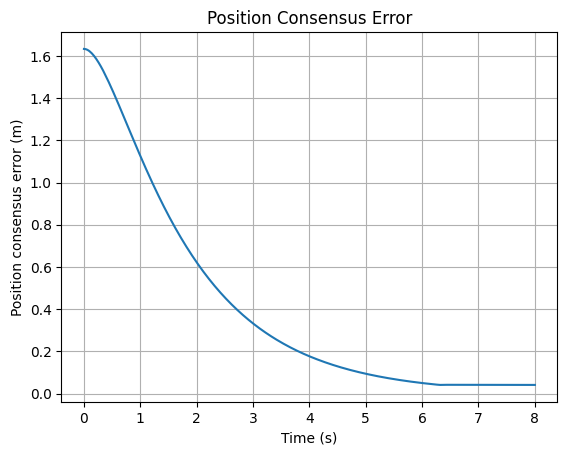

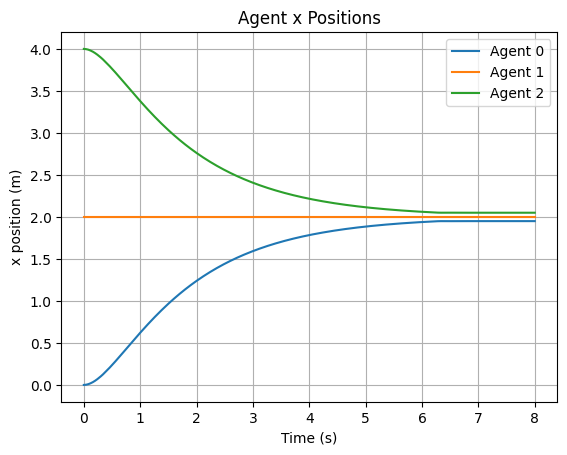

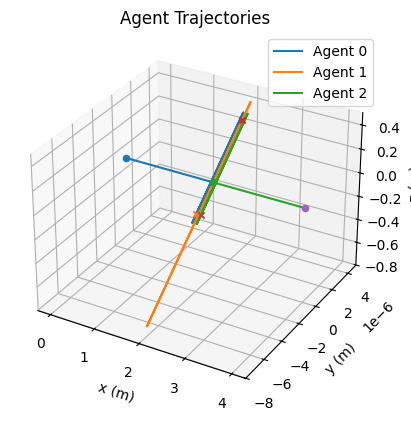

In [ ]:
# -----------------------------
# Simulate with logging
# -----------------------------

logger = sim.simulate_with_logging(
    duration=8.0,
    realtime_rate=1.0,
    log_dt=0.02
)

# -----------------------------
# Final states
# -----------------------------

states = sim.get_all_agent_states()

for agent_id, state in states.items():
    print("Agent:", agent_id)
    print("Final position:", state.position)
    print("Final velocity:", state.linear_velocity)
    print()

# -----------------------------
# Plots
# -----------------------------

plot_consensus_error(logger)
plot_agent_x_positions(logger)
plot_3d_trajectories(logger)

In [ ]:
data = logger.as_arrays()

print("Initial consensus error:", data["consensus_error"][0])
print("Final consensus error:", data["consensus_error"][-1])

Initial consensus error: 1.632993161855452
Final consensus error: 0.040836010247775674


In [ ]:
def print_consensus_summary(logger):
    data = logger.as_arrays()

    initial_error = data["consensus_error"][0]
    final_error = data["consensus_error"][-1]

    reduction = initial_error - final_error

    if initial_error > 0:
        reduction_percent = 100.0 * reduction / initial_error
    else:
        reduction_percent = 0.0

    print("Initial consensus error:", initial_error)
    print("Final consensus error:", final_error)
    print("Error reduction:", reduction)
    print("Error reduction percentage:", reduction_percent, "%")

In [ ]:
print_consensus_summary(logger)

Initial consensus error: 1.632993161855452
Final consensus error: 0.040836010247775674
Error reduction: 1.5921571516076765
Error reduction percentage: 97.49931529404712 %


In [ ]:
def create_consensus_agents(env):
    """
    Create fresh agents for one consensus experiment.
    Use this function separately for each topology.
    """

    initial_positions = [
        np.array([0.0, 0.0, 2.0]),
        np.array([1.0, 0.0, 2.0]),
        np.array([3.0, 0.0, 2.0]),
        np.array([5.0, 0.0, 2.0]),
        np.array([8.0, 0.0, 2.0])
    ]

    colors = [
        (1.0, 0.2, 0.2, 1.0),
        (0.2, 1.0, 0.2, 1.0),
        (0.2, 0.2, 1.0, 1.0),
        (1.0, 0.8, 0.2, 1.0),
        (0.8, 0.2, 1.0, 1.0)
    ]

    agents = []

    for i, pos in enumerate(initial_positions):
        cfg = BodyConfig(
            mass=1.0,
            inertia_matrix=np.diag([0.1, 0.1, 0.1]),
            initial_position=pos,
            initial_linear_velocity=np.zeros(3),
            size=(0.03, 0.03, 0.03),
            color=colors[i]
        )

        controller = PositionConsensusController(
            kp=1.0,
            kd=2.0,
            force_limit=20.0,
            normalize_by_degree=False
        )

        agent = Agent(
            agent_id=i,
            config=cfg,
            controller=controller
        )

        agents.append(agent)

    return agents

In [ ]:
def run_topology_experiment(graph_name,
                            graph_builder,
                            duration=8.0,
                            log_dt=0.02):
    """
    Run one consensus experiment for a selected communication graph.
    """

    env = EnvironmentConfig(
        gravity=np.array([0.0, 0.0, 0.0])
    )

    agents = create_consensus_agents(env)

    agent_ids = [agent.id for agent in agents]

    comm_graph = graph_builder(agent_ids)

    print()
    print("Running topology:", graph_name)
    print("Edges:", comm_graph.edges())

    sim = MultiAgentSimulator(
        agents=agents,
        environment=env,
        communication_graph=comm_graph,
        time_step=0.001
    )

    logger = sim.simulate_with_logging(
        duration=duration,
        realtime_rate=0.0,
        log_dt=log_dt
    )

    return logger

In [ ]:
def plot_topology_consensus_errors(results):
    """
    Plot consensus error curves for different communication topologies.

    Parameters
    ----------
    results : dict
        graph_name -> SimulationLogger
    """

    plt.figure()

    for graph_name, logger in results.items():
        data = logger.as_arrays()

        time = data["time"]
        error = data["consensus_error"]

        plt.plot(time, error, label=graph_name)

    plt.xlabel("Time (s)")
    plt.ylabel("Position consensus error (m)")
    plt.title("Effect of Communication Topology on Consensus")
    plt.legend()
    plt.grid(True)
    plt.show()

In [ ]:
def print_topology_summary(results):
    """
    Print initial and final consensus errors for each topology.
    """

    print()
    print("Consensus Error Summary")
    print("-----------------------")

    for graph_name, logger in results.items():
        data = logger.as_arrays()

        initial_error = data["consensus_error"][0]
        final_error = data["consensus_error"][-1]

        if initial_error > 0:
            reduction_percent = 100.0 * (initial_error - final_error) / initial_error
        else:
            reduction_percent = 0.0

        print(graph_name)
        print("  Initial error:", initial_error)
        print("  Final error:", final_error)
        print("  Reduction:", reduction_percent, "%")
        print()


Running topology: Empty
Edges: []


INFO:drake:Meshcat listening for connections at http://localhost:7017
/tmp/ipykernel_4619/2121586738.py:108: DrakeDeprecationWarning: The parameter order and V_PB parameter name for SetFreeBodySpatialVelocity() are deprecated and will be removed 2026-06-01. Use context, body, V_JpJc instead.
  self.plant.SetFreeBodySpatialVelocity(
INFO:drake:Meshcat listening for connections at http://localhost:7018



Running topology: Chain
Edges: [(0, 1), (1, 2), (2, 3), (3, 4)]

Running topology: Ring
Edges: [(0, 1), (0, 4), (1, 2), (2, 3), (3, 4)]


INFO:drake:Meshcat listening for connections at http://localhost:7019
INFO:drake:Meshcat listening for connections at http://localhost:7020



Running topology: Complete
Edges: [(0, 1), (0, 2), (0, 3), (0, 4), (1, 2), (1, 3), (1, 4), (2, 3), (2, 4), (3, 4)]


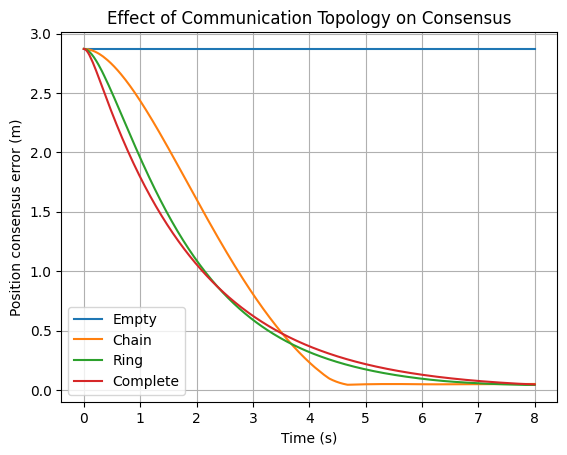


Consensus Error Summary
-----------------------
Empty
  Initial error: 2.8705400188814645
  Final error: 2.8705400188814645
  Reduction: 0.0 %

Chain
  Initial error: 2.8705400188814645
  Final error: 0.05039978024044305
  Reduction: 98.24424045967206 %

Ring
  Initial error: 2.8705400188814645
  Final error: 0.04246532003136807
  Reduction: 98.52065047858434 %

Complete
  Initial error: 2.8705400188814645
  Final error: 0.04667094786620383
  Reduction: 98.37414049066663 %



In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# -----------------------------
# Run topology comparison
# -----------------------------

results = {}

results["Empty"] = run_topology_experiment(
    graph_name="Empty",
    graph_builder=lambda agent_ids: CommunicationGraph.empty(agent_ids),
    duration=8.0,
    log_dt=0.02
)

results["Chain"] = run_topology_experiment(
    graph_name="Chain",
    graph_builder=lambda agent_ids: CommunicationGraph.chain(agent_ids),
    duration=8.0,
    log_dt=0.02
)

results["Ring"] = run_topology_experiment(
    graph_name="Ring",
    graph_builder=lambda agent_ids: CommunicationGraph.ring(agent_ids),
    duration=8.0,
    log_dt=0.02
)

results["Complete"] = run_topology_experiment(
    graph_name="Complete",
    graph_builder=lambda agent_ids: CommunicationGraph.complete(agent_ids),
    duration=8.0,
    log_dt=0.02
)

# -----------------------------
# Plot and summarize
# -----------------------------

plot_topology_consensus_errors(results)

print_topology_summary(results)